In [1]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel, AutoConfig, BertForSequenceClassification
from tqdm.notebook import tqdm
# model_name = "facebook/esm2_t33_650M_UR50D"
# model = AutoModel.from_pretrained(model_name)
# tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
# loss = nn.BCEWithLogitsLoss()

In [2]:
import pickle, json
import numpy as np
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
with open(f"{train_path}/cafa_dataset/prot_ids.json", "r") as f:
    prot_ids = json.load(f)
with open(f"{train_path}/cafa_dataset/rev_annot.pkl", "rb") as f:
    labels = pickle.load(f)
labeled_id = (np.asarray(labels.sum(axis=1)) > 1).flatten()
labels = labels[labeled_id, :]

In [3]:
from sklearn.decomposition import TruncatedSVD
clf = TruncatedSVD(128)
Xpca = clf.fit_transform(labels)

In [4]:
total_pos = 0; total_eq = 0
fp = 0; tp = 0; fn = 0; tn = 0
with torch.no_grad():
    for si in tqdm(range(0, labels.shape[0], 1024), total=labels.shape[0]//1024):
        ei = min(si+1024, labels.shape[0])
        Xpca_chunk = Xpca[si: ei, :]
        label_pca_inv = clf.inverse_transform(Xpca_chunk)
        label_pca_inv = label_pca_inv > 0.5
        label_ref = labels[si:ei, :].todense()
        label_eq = (label_pca_inv == label_ref)
        total_pos += label_pca_inv.sum()
        total_eq += label_eq.sum()
        tp += (label_eq & label_ref).sum()
        tn += (label_eq & (~label_ref)).sum()
        fn += ((~label_eq) & label_ref).sum()
        fp += ((~label_eq) & (~label_ref)).sum()

  0%|          | 0/150 [00:00<?, ?it/s]

In [5]:
prec = tp / (tp + fp)
rec = tp / (tp + fn)
print(prec, rec, (2*prec*rec)/(prec + rec))

0.9837875772338402 0.6514891909357102 0.7838758370695864


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualLayer(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.linear = nn.Linear(emb_dim, emb_dim)
        self.gelu = nn.GELU()
    def forward(self, x):
        return x + self.gelu(self.linear(x))

class GOVAE(nn.Module):
    def __init__(self, n_term, emb_dim=128, num_layer=3, res_layer=False):
        super().__init__()
        self.emb_dim = emb_dim
        self.gelu = nn.GELU()
        self.emb = nn.Linear(n_term, emb_dim)
        self.encoder_root = nn.Sequential(self.emb)
        for n in range(num_layer-1):
            self.encoder_root.append(ResidualLayer(emb_dim=emb_dim))
        self.mu_layer = nn.Linear(emb_dim, emb_dim)
        self.logvar_layer = nn.Linear(emb_dim, emb_dim)
        self.decoder = nn.Sequential()
        for n in range(num_layer):
            self.decoder.append(ResidualLayer(emb_dim=emb_dim))
        self.dec_emb = nn.Linear(emb_dim, n_term)
        self.decoder.append(self.dec_emb)

    def encode(self, x):
        z_root = self.encoder_root(x)
        mu =  self.mu_layer(z_root)
        logvar = self.logvar_layer(z_root)
        return mu, logvar
    
    def decode(self, z):
        return self.decoder(z)
    
go_vae = GOVAE(12000, emb_dim=128)
print(go_vae.encode(torch.zeros(12000)))

(tensor([ 0.0671, -0.0595,  0.0478, -0.0149, -0.0564, -0.0629, -0.0546, -0.0296,
         0.0354, -0.0216, -0.0656,  0.1004,  0.1159,  0.1159,  0.0412, -0.0015,
        -0.0234, -0.0188,  0.0029,  0.0250, -0.1166, -0.0057, -0.0907, -0.0283,
         0.0288,  0.0061, -0.0150, -0.0121, -0.0094, -0.0764, -0.0730, -0.0349,
        -0.0067,  0.0311, -0.0498, -0.0797,  0.0057,  0.0558,  0.0102,  0.0244,
         0.1201, -0.0281,  0.0466, -0.0095,  0.0374, -0.0208, -0.0380,  0.0224,
        -0.0046,  0.0566, -0.0597,  0.0691,  0.0563,  0.1177, -0.0761, -0.0114,
         0.0927, -0.0497,  0.0502,  0.0049, -0.0125, -0.0598, -0.0251, -0.0814,
        -0.0542,  0.0488,  0.0234,  0.0027,  0.0865,  0.0473, -0.0484,  0.0090,
        -0.0723, -0.0310,  0.0753,  0.0586,  0.0440, -0.0005,  0.0375, -0.0748,
         0.0726,  0.0073, -0.0665,  0.0671, -0.0261,  0.0566,  0.0384,  0.0573,
        -0.0224,  0.0353, -0.0043, -0.0859, -0.0397, -0.0653, -0.0490,  0.0468,
         0.0125,  0.0688,  0.0748, -0.0

In [14]:
from torch.utils.data import Dataset, DataLoader
class LabelDataset(Dataset):
    def __init__(self, labels):
        self.labels = labels
    def __len__(self):
        return self.labels.shape[0]
    def __getitem__(self, index):
        return torch.FloatTensor(self.labels[index].todense()).flatten()

label_dataset = LabelDataset(labels)
batch_size = 1024
label_loader = DataLoader(label_dataset, batch_size=batch_size, shuffle=True)
label_dataset[10].shape, next(iter(label_loader)).shape

(torch.Size([29185]), torch.Size([1024, 29185]))

In [ ]:
from tqdm.notebook import tqdm
device = torch.device('cuda:0')
bce_loss = nn.BCEWithLogitsLoss(reduction='sum')
from collections import defaultdict
metric_dict = defaultdict(list)
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

# go_vae = GOVAE(labels.shape[1], emb_dim=128).to(device)

def warmup_lr(epoch):
    if epoch < 4:
        return (epoch + 1) / 4
    else:
        return 1 - (epoch + 1) / 50

opt = torch.optim.Adam(go_vae.parameters(), lr=5e-4)
scheduler = LambdaLR(opt, warmup_lr)

for epoch in range(50):
    for x in tqdm(label_loader):
        x = x.to(device)
        opt.zero_grad()
        mu, logvar = go_vae.encode(x)
        s = torch.normal(0, 1, mu.shape, device=mu.device)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.shape[0]
        
        z = mu + s*torch.exp(logvar / 2)
        x_logit = go_vae.decode(z)
        recon_loss = F.binary_cross_entropy_with_logits(x_logit, x, reduction='sum') / x.shape[0]
        loss = kl_loss*0.1 + recon_loss

        metric_dict['kl_loss'].append(kl_loss.detach().cpu().item())
        metric_dict['ll'].append(recon_loss.detach().cpu().item())
        metric_dict['loss'].append(loss.detach().cpu().item())
        loss.backward()
        opt.step()
    scheduler.step()

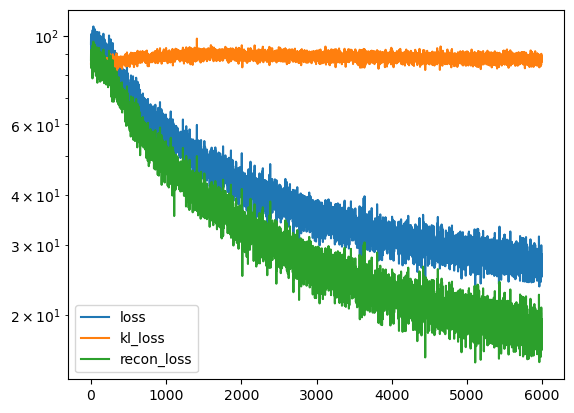

In [34]:
import matplotlib.pyplot as plt
plt.plot(metric_dict['loss'][100:], label='loss')
plt.plot(metric_dict['kl_loss'][100:], label='kl_loss')
plt.plot(metric_dict['ll'][100:], label='recon_loss')
plt.yscale('log')
plt.legend()

In [ ]:
with torch.no_grad():
    emb_l = []
    for si in tqdm(range(0, labels.shape[0], 500), total=labels.shape[0]//500):
        ei = min(si+500, labels.shape[0])
        x = torch.FloatTensor(labels[si:ei, :].todense()).to(device)
        z = go_vae.encode(x)
        emb_l.append(z[0])
    emb = torch.cat(emb_l)
print(emb.shape)
total_pos = 0; total_eq = 0
fp = 0; tp = 0; fn = 0; tn = 0
with torch.no_grad():
    for si in tqdm(range(0, labels.shape[0], 1024), total=labels.shape[0]//1024):
        ei = min(si+1024, labels.shape[0])
        emb_chunk = emb[si: ei, :]
        label_inv = (go_vae.decode(emb_chunk) > 3).cpu().numpy()
        label_ref = labels[si:ei, :].todense()
        label_eq = (label_inv == label_ref)
        total_pos += label_inv.sum()
        total_eq += label_eq.sum()
        tp += (label_eq & label_ref).sum()
        tn += (label_eq & (~label_ref)).sum()
        fn += ((~label_eq) & label_ref).sum()
        fp += ((~label_eq) & (~label_ref)).sum()
print(tp, tn, fn, fp)
prec = tp / (tp + fp)
rec = tp / (tp + fn)
print(prec, rec, (2*prec*rec)/(prec + rec))

In [8]:
class GOAE(nn.Module):
    def __init__(self, n_term, emb_dim=128, num_layer=3, res_layer=False):
        super().__init__()
        self.emb_dim = emb_dim
        self.gelu = nn.GELU()
        self.emb = nn.Linear(n_term, emb_dim)
        self.encoder = nn.Sequential(self.emb)
        for n in range(num_layer):
            self.encoder.append(ResidualLayer(emb_dim))
        self.decoder = nn.Sequential()
        for n in range(num_layer):
            self.decoder.append(ResidualLayer(emb_dim))
        self.dec_emb = nn.Linear(emb_dim, n_term)
        self.decoder.append(self.dec_emb)
        
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)

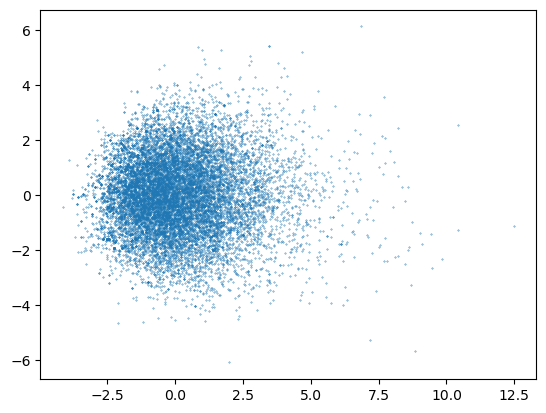

In [42]:
from sklearn.decomposition import PCA
clf = PCA(n_components=6)
pca_emb = clf.fit_transform(emb.cpu().numpy())
pca_emb.shape
import matplotlib.pyplot as plt
plt.scatter(pca_emb[::10, 0], pca_emb[::10, 5], s=0.1)
plt.show()

In [ ]:
from tqdm.notebook import tqdm
device = torch.device('cuda:0')
go_ae = GOAE(labels.shape[1], emb_dim=512).to(device)
bce_loss = nn.BCEWithLogitsLoss(reduction='mean')
from collections import defaultdict
metric_dict = defaultdict(list)
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

def warmup_lr(epoch):
    if epoch < 4:
        return (epoch + 1) / 4
    else:
        return 1 - (epoch + 1) / 50

opt = torch.optim.Adam(go_ae.parameters(), lr=3e-3)
scheduler = LambdaLR(opt, warmup_lr)

for epoch in range(50):
    for x in tqdm(label_loader):
        x = x.to(device)
        opt.zero_grad()
        z = go_ae.encode(x)
        x_logit = go_ae.decode(z)
        dec_ll = bce_loss(x_logit, x)
        loss = dec_ll
        metric_dict['loss'].append(loss.detach().cpu().item())
        loss.backward()
        opt.step()
    scheduler.step()


In [ ]:
from tqdm.notebook import tqdm
device = torch.device('cuda:0')
go_ae = GOAE(labels.shape[1], emb_dim=512).to(device)
bce_loss = nn.BCEWithLogitsLoss(reduction='mean')
from collections import defaultdict
metric_dict = defaultdict(list)
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

def warmup_lr(epoch):
    if epoch < 4:
        return (epoch + 1) / 4
    else:
        return 1 - (epoch + 1) / 50

opt = torch.optim.Adam(go_ae.parameters(), lr=3e-3)
scheduler = LambdaLR(opt, warmup_lr)

for epoch in range(50):
    for x in tqdm(label_loader):
        x = x.to(device)
        opt.zero_grad()
        z = go_ae.encode(x)
        x_logit = go_ae.decode(z)
        dec_ll = bce_loss(x_logit, x)
        loss = dec_ll
        metric_dict['loss'].append(loss.detach().cpu().item())
        loss.backward()
        opt.step()
    scheduler.step()


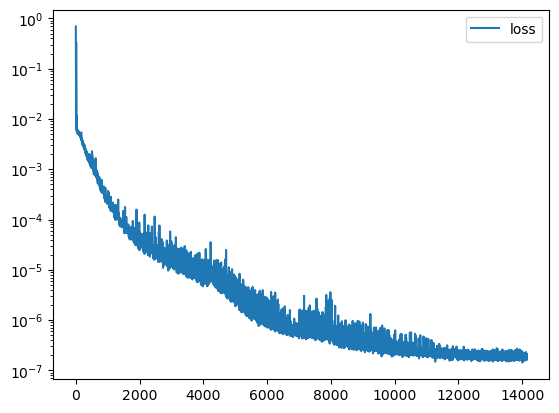

In [17]:
import matplotlib.pyplot as plt
plt.plot(metric_dict['loss'], label='loss')
plt.yscale('log')
plt.legend()

In [22]:
with torch.no_grad():
    emb_l = []
    for si in tqdm(range(0, labels.shape[0], 500), total=labels.shape[0]//500):
        ei = min(si+500, labels.shape[0])
        x = torch.FloatTensor(labels[si:ei, :].todense()).to(device)
        z = go_ae.encode(x)
        emb_l.append(z)
    emb = torch.cat(emb_l)
print(emb.shape)
total_pos = 0; total_eq = 0
fp = 0; tp = 0; fn = 0; tn = 0
with torch.no_grad():
    for si in tqdm(range(0, labels.shape[0], 1024), total=labels.shape[0]//1024):
        ei = min(si+1024, labels.shape[0])
        emb_chunk = emb[si: ei, :]
        label_inv = (go_ae.decode(emb_chunk) > 3).cpu().numpy()
        label_ref = labels[si:ei, :].todense()
        label_eq = (label_inv == label_ref)
        total_pos += label_inv.sum()
        total_eq += label_eq.sum()
        tp += (label_eq & label_ref).sum()
        tn += (label_eq & (~label_ref)).sum()
        fn += ((~label_eq) & label_ref).sum()
        fp += ((~label_eq) & (~label_ref)).sum()
print(tp, tn, fn, fp)
prec = tp / (tp + fp)
rec = tp / (tp + fn)
print(prec, rec, (2*prec*rec)/(prec + rec))

  0%|          | 0/150 [00:00<?, ?it/s]

In [24]:
print(tp, tn, fn, fp)
prec = tp / (tp + fp)
rec = tp / (tp + fn)
print(prec, rec, (2*prec*rec)/(prec + rec))

6100137 4484070462 21 0
1.0 0.9999965574662164 0.9999982787301455
